# day-18-rag-pipeline — worked solutions & answer key

Solutions to the exercises in [`../lesson.ipynb`](../lesson.ipynb), plus the self-check answer key. **Try each exercise yourself first** — the value is in the attempt, not the answer.

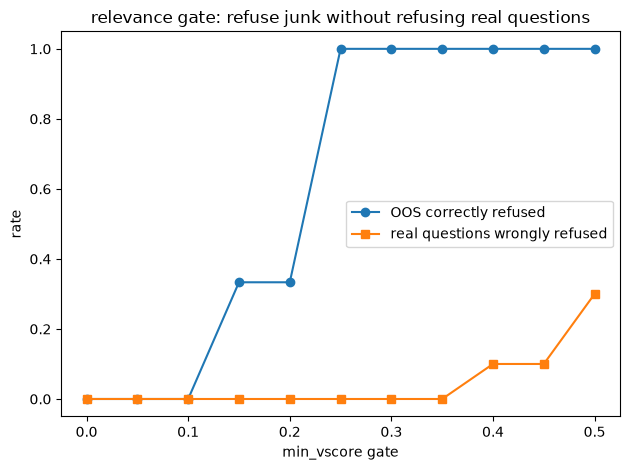

pick the largest threshold where 'wrongly refused' is still ~0 (here ~0.35)


In [9]:
# ---- Solution 3 ----  (gate decision uses only the vector score -- no LLM call needed)
import matplotlib.pyplot as plt
ths = np.linspace(0, 0.5, 11)
oos_gated = [np.mean([retrieve(q, k=3)[0]["vscore"] < th for q in OOS]) for th in ths]
real_gated = [np.mean([retrieve(q, k=3)[0]["vscore"] < th for q, _, _ in EVAL]) for th in ths]
plt.plot(ths, oos_gated, "o-", label="OOS correctly refused")
plt.plot(ths, real_gated, "s-", label="real questions wrongly refused")
plt.xlabel("min_vscore gate"); plt.ylabel("rate"); plt.legend()
plt.title("relevance gate: refuse junk without refusing real questions")
plt.tight_layout(); plt.show()
print("pick the largest threshold where 'wrongly refused' is still ~0 "
      f"(here ~{ths[max(i for i,r in enumerate(real_gated) if r==0)]:.2f})")

In [10]:
# ---- Solution 6 ----  (uses the ctx token estimates from the retrieval sweep -- no LLM)
def gen_cost(ctx_tokens, queries, out_tok=120, pin=1/1e6, pout=5/1e6, overhead=200):
    tin = ctx_tokens + overhead
    return queries * (tin*pin + out_tok*pout)
for k in [2, 6]:
    _, _, _, ctx = retrieval_metrics("hybrid", k)
    print(f"hybrid k={k}: ~{ctx:.0f} context tok/query -> "
          f"${gen_cost(ctx, 50_000):,.2f}/month at 50k queries (haiku pricing)")
print("\nS6: bigger k linearly raises the input-token bill; the win has to be worth it on the")
print("    faithfulness numbers. Prompt caching the static instructions cuts the fixed part.")

hybrid k=2: ~154 context tok/query -> $47.73/month at 50k queries (haiku pricing)


hybrid k=6: ~354 context tok/query -> $57.72/month at 50k queries (haiku pricing)

S6: bigger k linearly raises the input-token bill; the win has to be worth it on the
    faithfulness numbers. Prompt caching the static instructions cuts the fixed part.


### Solutions 1, 2, 4, 5 (sketch)

**S1:** `from sentence_transformers import CrossEncoder; ce = CrossEncoder("cross-encoder/
ms-marco-MiniLM-L-6-v2")`; score `ce.predict([(query, c["text"]) for c in cands])`, sort desc,
keep 4. Rerankers typically lift faithfulness/correctness several points because they judge
query–chunk relevance jointly instead of via independent embeddings — at ~10–50ms extra per
query for a small cross-encoder.

**S2:** wrap the ingest cell in `for max_chars in [200, 400, 800]:`, rebuild `CHUNKS`/`CVEC`,
`run_eval(RAGPipeline())`. Expect a sweet spot near 400: 200 fragments the dollar amounts,
800 dilutes them and pushes token cost up.

**S4:** e.g. *"what is the hotel cap in New York"* — if only the generic "$250/night in most
cities" chunk is retrieved, a model that already "knows" NYC hotels are pricey might answer
"$350" correctly *without that fact in context*. It's dangerous because your faithfulness
metric — the thing that catches hallucinations — is what failed; the correct answer here is
luck, and the same setup will confidently produce a wrong "$350" for a city where the real cap
differs.

**S5:** removing the exact-refusal clause usually drops `oos_abstention` sharply — the model
falls back to being helpful and answers out-of-scope questions from its own knowledge. The
precise, mandatory refusal string is doing real work.

### Answer key
1. Chunking (Day 17), embeddings (Day 13), vector store (Day 15), hybrid retrieval + RRF
   (Day 13), grounded prompt (Day 16), generation (Anthropic API, Week 8 preview) — scored by
   an eval harness (Day 06 / Week 9).
2. They fail on different queries: BM25 nails exact/rare terms (codes, dollar amounts, names),
   dense nails paraphrase and no-lexical-overlap. RRF takes whichever ranked the true chunk
   highly, so the fused result is more robust than either alone.
3. It stops low-similarity retrievals from reaching the LLM, so out-of-scope questions get a
   clean "I don't know" instead of a confident fabrication. Failure mode: set too high, it
   also refuses legitimate questions whose best chunk scores modestly.
4. Faithfulness = the gold fact is actually present in the retrieved context. Correctness =
   the answer contains the gold fact. An answer can be correct without being faithful (the
   model supplied the fact from its own weights, not the context) — that's an unmonitored
   hallucination risk.
5. The prompt carries `k` retrieved chunks plus instructions on every call, while the answer
   is short — so input ≫ output tokens. Prompt caching (cache the static system prompt / any
   fixed preamble) cuts the repeated input cost the most.
6. The retriever often isn't surfacing the passage that contains the answer, but the model is
   answering correctly anyway from its training knowledge. Not safe: on questions where the
   model's prior is wrong or your policy differs from the world default, it will be confidently
   wrong with no signal. Fix the retriever (rerank, chunking, hybrid), don't celebrate the 0.9.
7. Correctness and faithfulness-use both rise (a frontier model actually reads the context and
   obeys the cite/refuse instructions), abstention on OOS becomes near-perfect, latency drops
   or holds, and you gain a real per-token dollar cost to optimise. The retrieval numbers
   (source_precision) don't change — that's upstream of the model.